# Advertising Sales Prediction using Machine Learning 
## Problem Statement

Predict product sales based on advertising budgets spent on:
- TV Advertising
- Radio Advertising
- Newspaper Advertising

## Import Libraries

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings

import warnings
warnings.filterwarnings('ignore')

# Machine Learning

from sklearn.model_selection import train_test_split

# Models

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [3]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Dataset Overview

In [4]:
print(df.shape)

(200, 5)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## Remove Unnecessary Column

In [7]:
df.drop('Unnamed: 0',axis=1,inplace=True)

## Missing Values

In [9]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Duplicate Values

In [10]:
df.duplicated().sum()

0

## EDA

### Sales Distribution

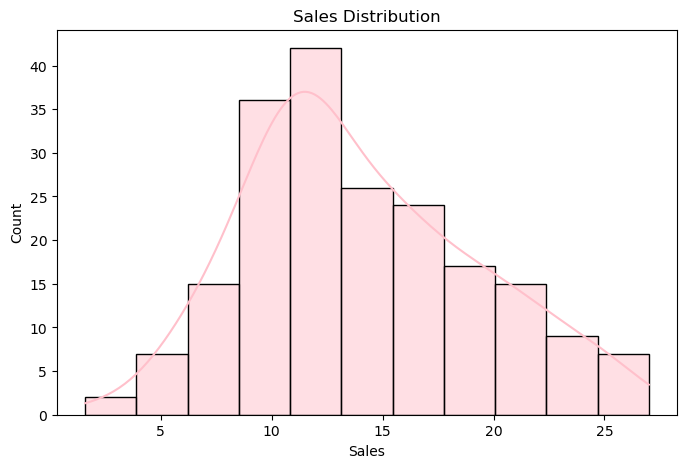

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Sales'],
    kde=True,
    color='pink'
)

plt.title("Sales Distribution")

plt.show()

#### Observation
- Sales values appear approximately normally distributed.

## Tv vs Sales

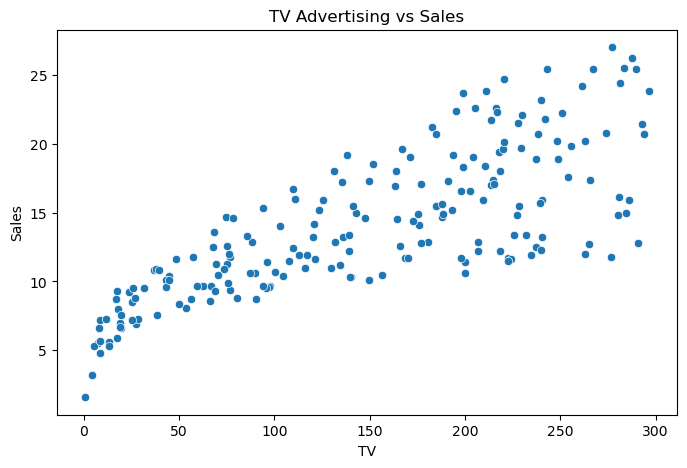

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("TV Advertising vs Sales")

plt.show()

Strong positive relationship exists between TV advertising and sales.

## Radio vs Sales

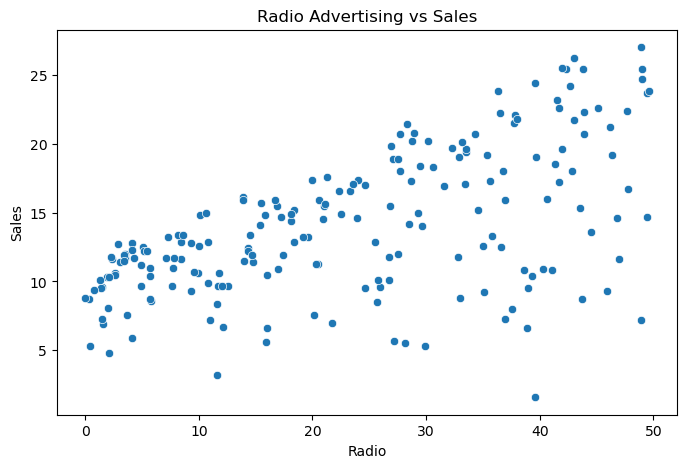

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Radio',
    y='Sales',
    data=df
)

plt.title("Radio Advertising vs Sales")

plt.show()

## Newspaper vs Sales

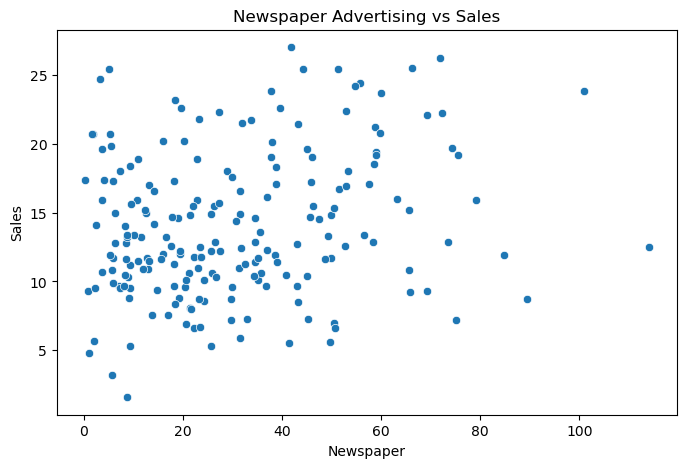

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Newspaper',
    y='Sales',
    data=df
)

plt.title("Newspaper Advertising vs Sales")

plt.show()

Newspaper advertising shows a weaker relationship with sales.

### Pairplot

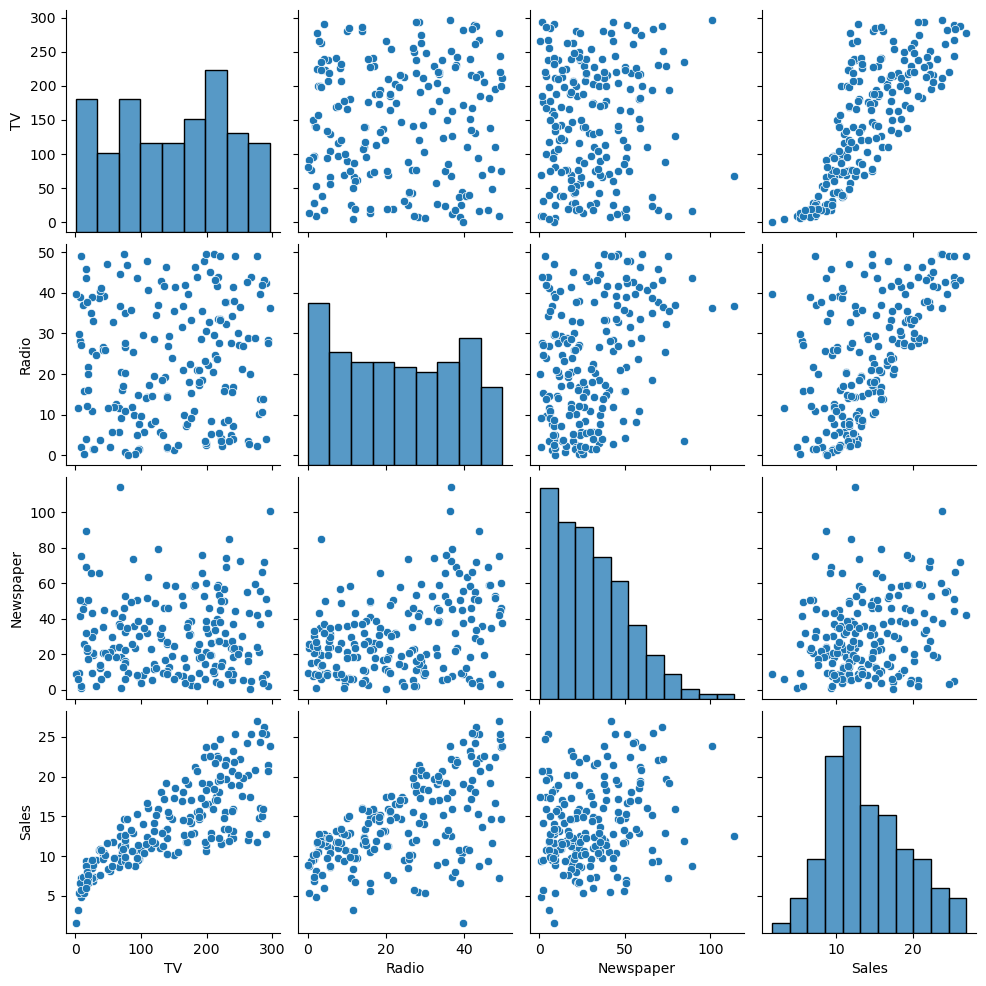

In [18]:
sns.pairplot(df)

plt.show()

### Correlation Heatmap

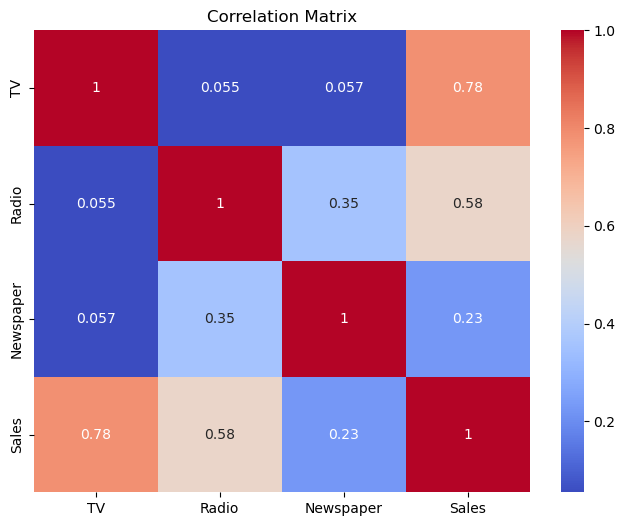

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

TV advertising has the highest correlation with Sales.

## Feature Selection

In [20]:
X = df.drop('Sales',axis=1)
y = df['Sales']

## Train test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Linear Regressio

In [22]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(X_test)

### Evaluation

In [23]:
print("Linear Regression")

print("MAE:",mean_absolute_error(y_test,y_pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print("R2 Score:",r2_score(y_test,y_pred_lr))

Linear Regression
MAE: 1.4607567168117606
RMSE: 1.7815996615334502
R2 Score: 0.899438024100912


## Ridge Regression

In [24]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train,y_train)

y_pred_ridge = ridge.predict(X_test)

### Evalution

In [34]:
print("Ridge Regression")
print("MAE:",mean_absolute_error(y_test,y_pred_ridge))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_ridge)))
print("R2 Score:",r2_score(y_test,y_pred_ridge))

Ridge Regression
MAE: 1.4607656112869642
RMSE: 1.7815989481622212
R2 Score: 0.89943810463304


## Random Forest

In [26]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

### Evaluation

In [35]:
print("Random Forest")
print("MAE:",mean_absolute_error(y_test,y_pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred_rf)))
print("R2 Score:",r2_score(y_test,y_pred_rf))

Random Forest
MAE: 0.6200999999999988
RMSE: 0.7685910811348248
R2 Score: 0.9812843792541843


In [28]:
print("Train R2:",rf.score(X_train,y_train))
print("Test R2:",rf.score(X_test,y_test))

Train R2: 0.9963471037158417
Test R2: 0.9812843792541843


## Model Comparison

In [29]:
results = pd.DataFrame({
    "Model":["Linear Regression","Ridge Regression","Random Forest"],
    "R2 Score":[r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_ridge),
        r2_score(y_test,y_pred_rf)]
})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,R2 Score
2,Random Forest,0.981284
1,Ridge Regression,0.899438
0,Linear Regression,0.899438


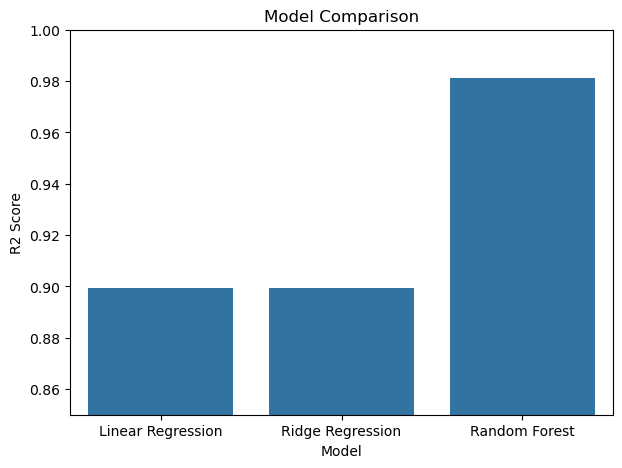

In [37]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results,
    palette='set'
)

plt.title("Model Comparison")
plt.ylim(0.85,1.0)

plt.show()

## Actual vs Predicted Sales

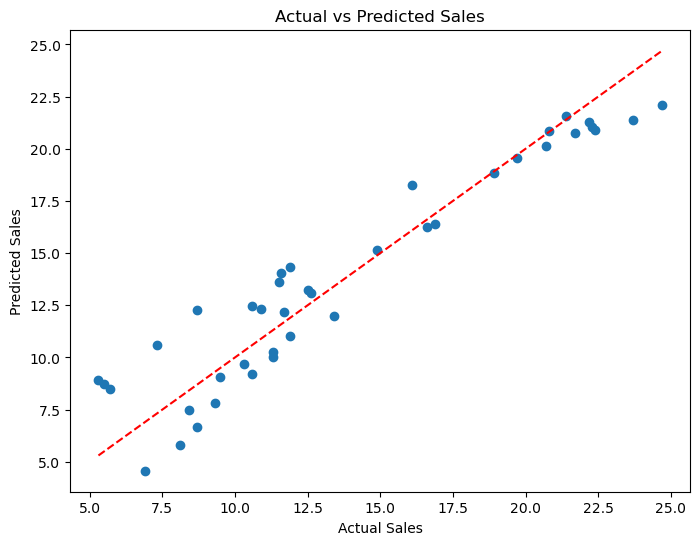

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_lr)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
    'r--')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

## Feature Importance

In [31]:
importance = pd.DataFrame({
    "Feature":
    X.columns,
    "Importance":
    rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


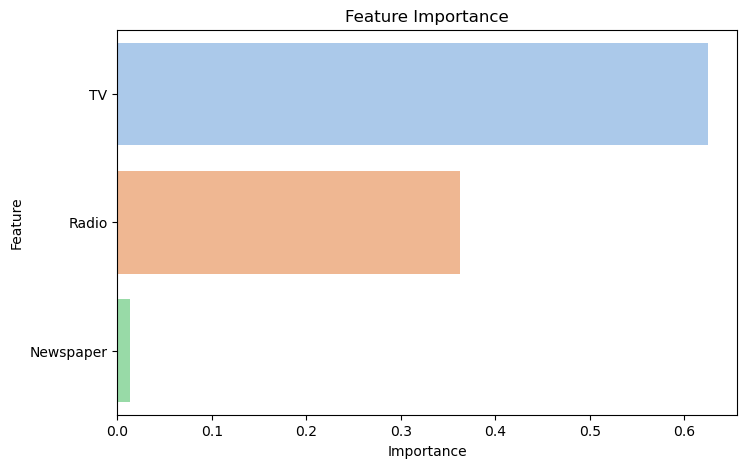

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x='Importance',y='Feature',data=importance,palette='pastel',)
plt.title("Feature Importance")
plt.show()

## Conclusion

This project successfully predicted product sales using advertising expenditure data.

Three machine learning models were evaluated:

- Linear Regression
- Ridge Regression
- Random Forest Regression

Among all models, Random Forest Regression achieved the best performance with an R² Score of 0.981.

Feature importance analysis revealed that TV advertising was the most influential factor affecting sales, followed by Radio advertising. Newspaper advertising had very little impact on sales.

The model demonstrated excellent generalization performance with a Training R² Score of 0.996 and a Testing R² Score of 0.981, indicating minimal overfitting.

Therefore, Random Forest Regression was selected as the final model for sales prediction.